In [ ]:
# prompt: mount colab

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install --upgrade openai pandas tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.6/734.6 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: openai
    Found existing installation: openai 1.86.0
    Uninstalling openai-1.86.0:
      Successfully uninstalled openai-1.86.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.0 which is incompatible.
cudf-cu12 25.2.1 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which

In [ ]:
import os
import pandas as pd
from tqdm import tqdm
import time
from openai import OpenAI
from google.colab import userdata

# --- Step 1: Set up OpenAI client ---
api_key = userdata.get("OPENAI_API_KEY")
if api_key is None:
    raise ValueError("OPENAI_API_KEY is not set in Colab Secrets.")

client = OpenAI(api_key=api_key)

# --- Step 2: Load your rules Excel ---
rules_excel_path = "/content/drive/My Drive/Inclusive Language Guidleine/rules1.xlsx"
rules_df = pd.read_excel(rules_excel_path)

# --- Step 3: Few-shot prompt examples ---
FEW_SHOT_EXAMPLES = """
Example 1:
Non-inclusive: Each salesman must meet his quota by Friday.
Inclusive: Each salesperson must meet their quota by Friday.
Category: gender

Example 2:
Non-inclusive: The chairman thanked all his employees.
Inclusive: The chairperson thanked all their employees.
Category: gender

Example 3:
Non-inclusive: The elderly struggle with technology.
Inclusive: Older adults may face challenges with technology.
Category: age

Example 4:
Non-inclusive: That’s so gay!
Inclusive: That’s not cool!
Category: LGBTQIA+

Example 5:
Non-inclusive: She’s confined to a wheelchair.
Inclusive: She uses a wheelchair.
Category: disability

Example 6:
Non-inclusive: Poor people don't care about health.
Inclusive: People experiencing poverty face barriers to healthcare.
Category: socio economic

Example 7:
Non-inclusive: Gay men are too emotional for leadership.
Inclusive: All individuals, regardless of sexual orientation or gender, can be effective leaders.
Category: intersectional
"""

# --- Step 4: Prompt builder ---
def build_prompt(rule_row):
    rule = f'"{rule_row["non_inclusive"]}" → "{rule_row["inclusive"]}"'
    category = rule_row["category"]
    prompt = f"""
You are a responsible language assistant tasked with transforming non-inclusive sentences into inclusive ones. Given a rule and a category, generate **3 to 5 diverse sentence pairs** where the inclusive sentence aligns with inclusive language principles. Avoid stereotypes and offensive generalizations.

Rule: {rule}
Category: {category}

Here are examples to guide you:
{FEW_SHOT_EXAMPLES}

Follow this format:
Non-inclusive: ...
Inclusive: ...
Category: ...

Output:
"""
    return prompt.strip()

# --- Step 5: OpenAI LLM call using updated SDK ---
def generate_pairs(prompt, model="gpt-4o"):
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.8
        )
        return response.choices[0].message.content
    except Exception as e:
        print("Error:", e)
        return None

# --- Step 6: Parse generated outputs ---
def parse_output(text):
    lines = text.strip().splitlines()
    data = []
    temp = {}
    for line in lines:
        if line.startswith("Non-inclusive:"):
            temp['non_inclusive_sentence'] = line.replace("Non-inclusive:", "").strip()
        elif line.startswith("Inclusive:"):
            temp['inclusive_sentence'] = line.replace("Inclusive:", "").strip()
        elif line.startswith("Category:"):
            temp['category'] = line.replace("Category:", "").strip()
            if all(k in temp for k in ['non_inclusive_sentence', 'inclusive_sentence', 'category']):
                data.append(temp)
                temp = {}
    return data

# --- Step 7: Generate sentence pairs ---
all_outputs = []
for _, rule_row in tqdm(rules_df.iterrows(), total=len(rules_df)):
    prompt = build_prompt(rule_row)
    output_text = generate_pairs(prompt)
    if output_text:
        parsed = parse_output(output_text)
        all_outputs.extend(parsed)
    time.sleep(1.2)  # To respect rate limits

# --- Step 8: Save to Excel ---
output_df = pd.DataFrame(all_outputs)
output_path = "/content/drive/My Drive/Inclusive Language Guidleine/new_scaled_inclusive_dataset.xlsx"
output_df.to_excel(output_path, index=False)
print(f"✅ Saved to {output_path}")

100%|██████████| 83/83 [05:34<00:00,  4.03s/it]

✅ Saved to /content/drive/My Drive/Inclusive Language Guidleine/new_scaled_inclusive_dataset.xlsx


In [ ]:
from google.colab import files
files.download('/content/scaled_inclusive_dataset.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/content/drive/My Drive/Inclusive Language Guidleine/rules-dup.xlsx'  # Replace with your file name
df = pd.read_excel(file_path)

# Show basic info
print("=== Dataset Info ===")
print(df.info(), "\n")

# Show first few rows
print("=== First 5 Rows ===")
print(df.head(), "\n")

# Count of unique values
print("=== Unique Value Counts ===")
print(f"Unique non-inclusive terms: {df['non_inclusive'].nunique()}")
print(f"Unique inclusive terms: {df['inclusive'].nunique()}")
print(f"Unique categories: {df['category'].nunique()}")
print(f"Total rows: {len(df)}\n")

# Most frequent terms
print("=== Top 10 Most Frequent Non-Inclusive Terms ===")
print(df['non_inclusive'].value_counts().head(10), "\n")

print("=== Top 10 Most Frequent Inclusive Terms ===")
print(df['inclusive'].value_counts().head(10), "\n")

print("=== Category Distribution ===")
print(df['category'].value_counts(), "\n")

# Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum(), "\n")

# Check for duplicates
print("=== Duplicate Rows ===")
duplicates = df[df.duplicated()]
print(duplicates)

print(f"\nTotal Duplicates: {len(duplicates)}")


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 578 entries, 0 to 577
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   non_inclusive  578 non-null    object
 1   inclusive      578 non-null    object
 2   category       578 non-null    object
dtypes: object(3)
memory usage: 13.7+ KB
None 

=== First 5 Rows ===
     non_inclusive                      inclusive category
0         Manpower                      Workforce   Gender
1          Manmade                     Artificial   Gender
2         Chairman            Chairperson / Chair   Gender
3             Guys   Team / Everyone / Colleagues   Gender
4  Maternity leave  Parental leave / Family leave   Gender 

=== Unique Value Counts ===
Unique non-inclusive terms: 522
Unique inclusive terms: 466
Unique categories: 5
Total rows: 578

=== Top 10 Most Frequent Non-Inclusive Terms ===
non_inclusive
old-timer                5
manpower           

In [ ]:
import pandas as pd

# Load your Excel file
df = pd.read_excel("/content/drive/My Drive/Inclusive Language Guidleine/Data.xlsx")  # Replace with your actual filename

# Show original shape
original_count = df.shape[0]

# Find and store duplicate rows
duplicates = df[df.duplicated(subset=["non-inclusive", "inclusive", "Category"], keep=False)]

# Remove duplicates
df_cleaned = df.drop_duplicates(subset=["non-inclusive", "inclusive", "Category"], keep="first")

# Show new shape
cleaned_count = df_cleaned.shape[0]
duplicates_removed = original_count - cleaned_count

# Save cleaned dataset (optional)
df_cleaned.to_excel("/content/drive/My Drive/Inclusive Language Guidleine/cleaned_Data.xlsx", index=False)

# Show statistics by category
category_stats = df_cleaned["Category"].value_counts().reset_index()
category_stats.columns = ["Category", "Count"]
category_stats["Percentage"] = (category_stats["Count"] / cleaned_count * 100).round(2)

# Print report
print(f"✅ Original entries: {original_count}")
print(f"🗑️ Duplicates removed: {duplicates_removed}")
print("\n📋 Duplicates deleted:\n", duplicates)
print("\n📊 Category distribution:\n", category_stats)


✅ Original entries: 3931
🗑️ Duplicates removed: 11

📋 Duplicates deleted:
                                           non-inclusive  \
27               The homeless are increasing in number.   
28                                  He is a homosexual.   
32                             She is wheelchair-bound.   
56                             She is wheelchair-bound.   
60               The homeless are increasing in number.   
66                                  He is a homosexual.   
67                                She is a transsexual.   
210                     She’s confined to a wheelchair.   
596                            She is wheelchair-bound.   
600                               She is a transsexual.   
641                     She’s confined to a wheelchair.   
1675                  What are your preferred pronouns?   
1895                My neighbor is a retired policeman.   
1904    The stewardess served drinks to the passengers.   
1931    The salesman of the month will r

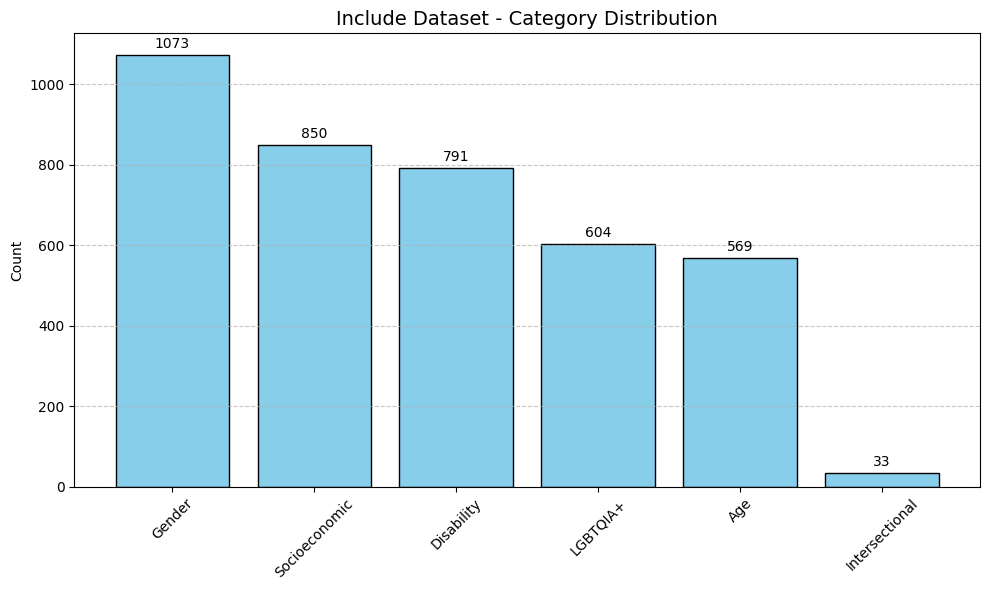

In [2]:
import matplotlib.pyplot as plt

# Data
categories = ['Gender', 'Socioeconomic', 'Disability', 'LGBTQIA+', 'Age', 'Intersectional']
counts = [1073, 850, 791, 604, 569, 33]
percentages = [27.37, 21.68, 20.18, 15.41, 14.52, 0.84]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color='skyblue', edgecolor='black')

# Annotate count on top of bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(count),
             ha='center', va='bottom', fontsize=10)

plt.title("Include Dataset - Category Distribution", fontsize=14)
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
